In [56]:
import warnings
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak", category=UserWarning)

In [87]:
import matplotlib.pyplot as plt
from sklearn import metrics, datasets, tree, cluster, mixture
from sklearn.model_selection import train_test_split
from sklearn.metrics import davies_bouldin_score
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

data = datasets.load_breast_cancer()
X,y= data.data, data.target

def k_means(n_clusters, data = X, debug = False):
    # parameterize clustering
    kmeans_algo = cluster.KMeans(n_clusters=n_clusters,algorithm='lloyd',init='random',n_init=1)

    # learn the model
    kmeans_model = kmeans_algo.fit(data)

    # return centroids
    kmeans_model.cluster_centers_
    labels = kmeans_model.labels_

    if debug:
        print("means:\n",kmeans_model.cluster_centers_)
        print("Davies Bouldin:",davies_bouldin_score(data, labels))

    print("Silhouette:",metrics.silhouette_score(data, labels, metric='euclidean'))
    return labels

def EM_clustering(n_clusters, data = X, debug = False):
    # learn EM with multivariate Gaussian assumption
    em_algo = GaussianMixture(n_components=n_clusters, covariance_type='full',n_init=1) 
    em_model = em_algo.fit(data)
    labels_em= em_model.predict(data)

    # describe EM solution
    if debug:
        print("means:\n",em_model.means_,"\n\ncovariances:\n",em_model.covariances_)
        print("Davies Bouldin:",davies_bouldin_score(data, labels_em))

    print("Silhouette:",metrics.silhouette_score(data, labels_em, metric='euclidean'))
    return labels_em

def test_clustering(n_clusters, data = X, debug = False):

    print(f"K-means, cluster = {n_clusters}:")
    _ = k_means(n_clusters, data, debug)
    print("-----==-----")
    print(f"EM_clustering, cluster = {n_clusters}:")
    _ = EM_clustering(n_clusters, data, debug)

def pca(debug = False, func = None):
    # learn the transformation (components as linear combination of features)
    pca = PCA(n_components=2)
    X_pca = pca.fit(X).transform(X)

    if func:
        labels = func(n_clusters = 2, data = X_pca, debug = debug)
    else:
        labels = y

    if debug:
        print("Components:\n",pca.components_)

    plt.scatter(X_pca[:,0], X_pca[:,1],c=labels)
    plt.show()

# ex 2 a)

In [122]:
test_clustering(n_clusters=2)

K-means, cluster = 2:
Silhouette: 0.6972646156059464
-----==-----
EM_clustering, cluster = 2:
Silhouette: 0.5315172918032405


Which clustering, k_means or EM-Clustering is better?

justification

# ex 2 b)

In [123]:
test_clustering(n_clusters=5)

K-means, cluster = 5:
Silhouette: 0.5071395181003269
-----==-----
EM_clustering, cluster = 5:
Silhouette: 0.43043979963111195


Why are the results worse (better) than when we clustered with 2 clusters in a)? (one sentence)

justification

# ex 2 c)

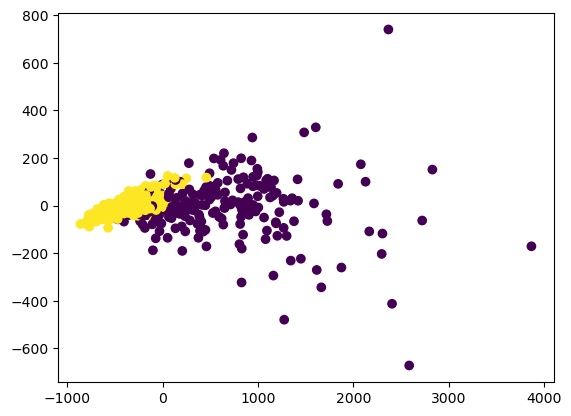

In [121]:
pca()

Plot the scatter plot. Can the two classes be separated? (one sentence)

Justification

# ex 2 d)

Silhouette: 0.6984195775999954


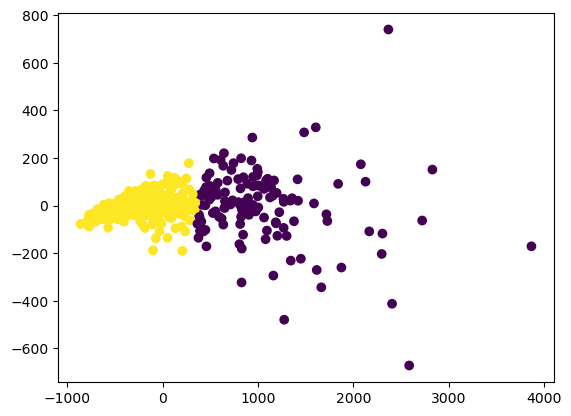

In [95]:
pca(debug=False, func= k_means)

Silhouette: 0.5865823748565954


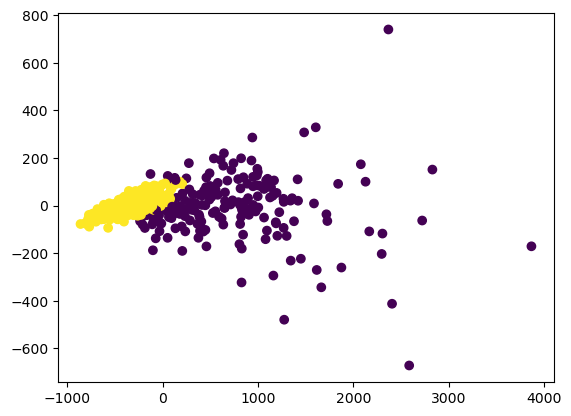

In [97]:
pca(debug=False, func= EM_clustering)

Which clustering, k_means or EM-Clustering is better? Why are the silhouette values different to the values in a)? (one/two sentence/s)

justification